In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas.tseries.offsets import MonthEnd

from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics

from sklearn.metrics import mean_absolute_error

from itertools import product

from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from tqdm import tqdm
from typing import Union

import warnings
warnings.filterwarnings('ignore')

In [4]:
plt.rcParams['figure.figsize'] = (10, 7.5)
plt.rcParams['axes.grid'] = False

Source: https://www150.statcan.gc.ca/t1/tbl1/en/tv.action?pid=1810000201

In [5]:
df = pd.read_csv('../data/monthly_avg_retail_price_food_canada.csv')
df.head()

,REF_DATE,GEO,DGUID,Products,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,1995-01,Canada,2016A000011124,"Round steak, 1 kilogram",Dollars,81,units,0,v735165,1.1,10.17,NaN,NaN,NaN,2
1,1995-02,Canada,2016A000011124,"Round steak, 1 kilogram",Dollars,81,units,0,v735165,1.1,10.29,NaN,NaN,NaN,2
2,1995-03,Canada,2016A000011124,"Round steak, 1 kilogram",Dollars,81,units,0,v735165,1.1,10.12,NaN,NaN,NaN,2
3,1995-04,Canada,2016A000011124,"Round steak, 1 kilogram",Dollars,81,units,0,v735165,1.1,10.38,NaN,NaN,NaN,2
4,1995-05,Canada,2016A000011124,"Round steak, 1 kilogram",Dollars,81,units,0,v735165,1.1,10.00,NaN,NaN,NaN,2


In [6]:
df.shape

(16166, 15)

In [7]:
df = df[df['Products'] == 'Round steak, 1 kilogram']
df.head()

,REF_DATE,GEO,DGUID,Products,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,1995-01,Canada,2016A000011124,"Round steak, 1 kilogram",Dollars,81,units,0,v735165,1.1,10.17,NaN,NaN,NaN,2
1,1995-02,Canada,2016A000011124,"Round steak, 1 kilogram",Dollars,81,units,0,v735165,1.1,10.29,NaN,NaN,NaN,2
2,1995-03,Canada,2016A000011124,"Round steak, 1 kilogram",Dollars,81,units,0,v735165,1.1,10.12,NaN,NaN,NaN,2
3,1995-04,Canada,2016A000011124,"Round steak, 1 kilogram",Dollars,81,units,0,v735165,1.1,10.38,NaN,NaN,NaN,2
4,1995-05,Canada,2016A000011124,"Round steak, 1 kilogram",Dollars,81,units,0,v735165,1.1,10.00,NaN,NaN,NaN,2


In [8]:
df.columns

Index(['REF_DATE', 'GEO', 'DGUID', 'Products', 'UOM', 'UOM_ID',
       'SCALAR_FACTOR', 'SCALAR_ID', 'VECTOR', 'COORDINATE', 'VALUE', 'STATUS',
       'SYMBOL', 'TERMINATED', 'DECIMALS'],
      dtype='str')

In [9]:
cols_to_drop = ['GEO', 'DGUID', 'Products', 'UOM', 'UOM_ID',
       'SCALAR_FACTOR', 'SCALAR_ID', 'VECTOR', 'COORDINATE', 'STATUS',
       'SYMBOL', 'TERMINATED', 'DECIMALS']

df = df.drop(cols_to_drop, axis=1)
df.head()

,REF_DATE,VALUE
0,1995-01,10.17
1,1995-02,10.29
2,1995-03,10.12
3,1995-04,10.38
4,1995-05,10.00


In [10]:
df.shape

(323, 2)

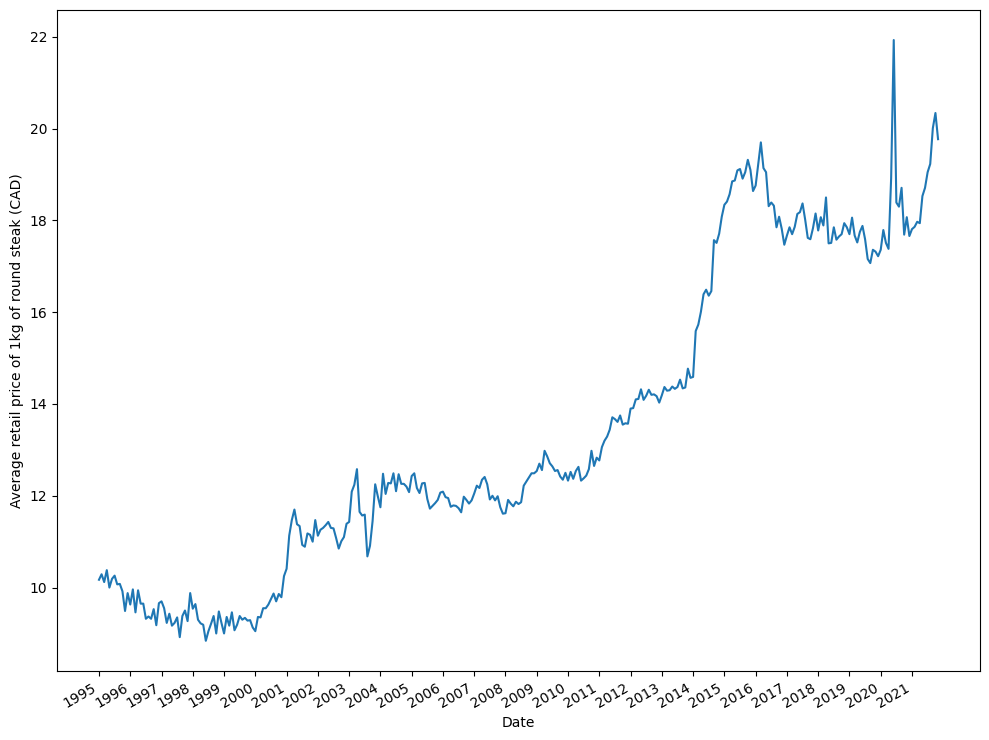

In [11]:
fig, ax = plt.subplots()

ax.plot(df['VALUE'])
ax.set_xlabel('Date')
ax.set_ylabel('Average retail price of 1kg of round steak (CAD)')

plt.xticks(np.arange(0, 322, 12), np.arange(1995, 2022, 1))

fig.autofmt_xdate()
plt.tight_layout()

In [12]:
df.columns = ['ds', 'y']

In [13]:
df['ds'] = pd.to_datetime(df['ds']) + MonthEnd(1)

df.head()

,ds,y
0,1995-01-31,10.17
1,1995-02-28,10.29
2,1995-03-31,10.12
3,1995-04-30,10.38
4,1995-05-31,10.00


In [14]:
train = df[:-36]
test = df[-36:]

train.tail()

,ds,y
282,2018-07-31,17.85
283,2018-08-31,17.58
284,2018-09-30,17.65
285,2018-10-31,17.70
286,2018-11-30,17.94


In [15]:
param_grid = {
    'changepoint_prior_scale': [0.01, 0.1, 1.0],
    'seasonality_prior_scale': [0.1, 1.0, 10.0]
}

params = [dict(zip(param_grid.keys(), v)) for v in product(*param_grid.values())]

mses = []

cutoffs = pd.date_range(start='2000-01-31', end=train['ds'].max() - pd.Timedelta('365 days'), freq='36ME')

for param in params:
    m = Prophet(**param)
    m.fit(train)
    
    df_cv = cross_validation(model=m, horizon='365 days', cutoffs=cutoffs)
    df_p = performance_metrics(df_cv, rolling_window=1)
    mses.append(df_p['mse'].values[0])
    
tuning_results = pd.DataFrame(params)
tuning_results['mse'] = mses

07:22:15 - cmdstanpy - INFO - Chain [1] start processing
07:22:15 - cmdstanpy - INFO - Chain [1] done processing
  0%|          | 0/6 [00:00<?, ?it/s]07:22:15 - cmdstanpy - INFO - Chain [1] start processing
07:22:15 - cmdstanpy - INFO - Chain [1] done processing
 17%|█▋        | 1/6 [00:00<00:00,  6.99it/s]07:22:15 - cmdstanpy - INFO - Chain [1] start processing
07:22:15 - cmdstanpy - INFO - Chain [1] done processing
 33%|███▎      | 2/6 [00:00<00:00,  5.22it/s]07:22:16 - cmdstanpy - INFO - Chain [1] start processing
07:22:16 - cmdstanpy - INFO - Chain [1] done processing
07:22:16 - cmdstanpy - INFO - Chain [1] start processing
07:22:16 - cmdstanpy - INFO - Chain [1] done processing
 67%|██████▋   | 4/6 [00:00<00:00,  7.54it/s]07:22:16 - cmdstanpy - INFO - Chain [1] start processing
07:22:16 - cmdstanpy - INFO - Chain [1] done processing
07:22:16 - cmdstanpy - INFO - Chain [1] start processing
07:22:16 - cmdstanpy - INFO - Chain [1] done processing
100%|██████████| 6/6 [00:00<00:00,  9

In [16]:
best_params = params[np.argmin(mses)]
print(best_params)

{'changepoint_prior_scale': 1.0, 'seasonality_prior_scale': 10.0}


In [17]:
m = Prophet(**best_params)
m.fit(train)

07:22:21 - cmdstanpy - INFO - Chain [1] start processing
07:22:21 - cmdstanpy - INFO - Chain [1] done processing


In [18]:
future = m.make_future_dataframe(periods=36, freq='ME')

In [19]:
forecast = m.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(12)

,ds,yhat,yhat_lower,yhat_upper
311,2020-12-31,19.191480,17.467913,20.948903
312,2021-01-31,19.185978,17.303981,20.899099
313,2021-02-28,19.521075,17.522170,21.340238
314,2021-03-31,19.444957,17.468278,21.330965
315,2021-04-30,19.569989,17.246381,21.700193
316,2021-05-31,19.513949,17.158622,21.729377
317,2021-06-30,19.440420,16.957338,21.661617
318,2021-07-31,19.402241,16.950413,21.857002
319,2021-08-31,19.389062,16.847144,21.905548
320,2021-09-30,19.398574,16.733353,22.006762


In [20]:
test[['yhat', 'yhat_lower', 'yhat_upper']] = forecast[['yhat', 'yhat_lower', 'yhat_upper']]
test.head()

,ds,y,yhat,yhat_lower,yhat_upper
287,2018-12-31,17.85,18.586882,17.907158,19.295299
288,2019-01-31,17.70,18.572571,17.919869,19.227696
289,2019-02-28,18.06,18.751356,18.045053,19.384556
290,2019-03-31,17.67,18.779519,18.146549,19.452845
291,2019-04-30,17.52,19.032962,18.337174,19.703904


In [21]:
test['Baseline'] = train['y'].iloc[-1]
test.head()

,ds,y,yhat,yhat_lower,yhat_upper,Baseline
287,2018-12-31,17.85,18.586882,17.907158,19.295299,17.94
288,2019-01-31,17.70,18.572571,17.919869,19.227696,17.94
289,2019-02-28,18.06,18.751356,18.045053,19.384556,17.94
290,2019-03-31,17.67,18.779519,18.146549,19.452845,17.94
291,2019-04-30,17.52,19.032962,18.337174,19.703904,17.94


In [22]:
baseline_mae = mean_absolute_error(test['y'], test['Baseline'])
prophet_mae = mean_absolute_error(test['y'], test['yhat'])

print(prophet_mae)
print(baseline_mae)

1.1572586968918155
0.6816666666666671


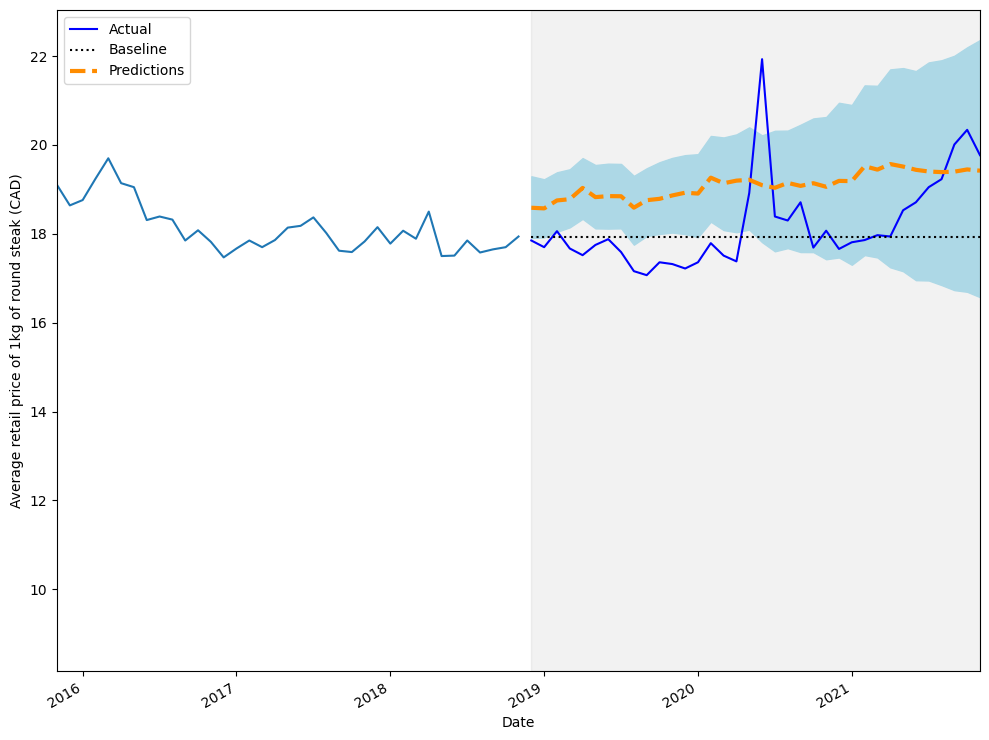

In [23]:
fig, ax = plt.subplots()

ax.plot(train['y'])
ax.plot(test['y'], 'b-', label='Actual')
ax.plot(test['Baseline'], 'k:', label='Baseline')
ax.plot(test['yhat'], color='darkorange', ls='--', lw=3, label='Predictions')

ax.set_xlabel('Date')
ax.set_ylabel('Average retail price of 1kg of round steak (CAD)')

ax.axvspan(287, 322, color='#808080', alpha=0.1)

ax.legend(loc='best')

plt.xticks(np.arange(0, 322, 12), np.arange(1995, 2022, 1))
plt.fill_between(x=test.index, y1=test['yhat_lower'], y2=test['yhat_upper'], color='lightblue')
plt.xlim(250, 322)

fig.autofmt_xdate()
plt.tight_layout()

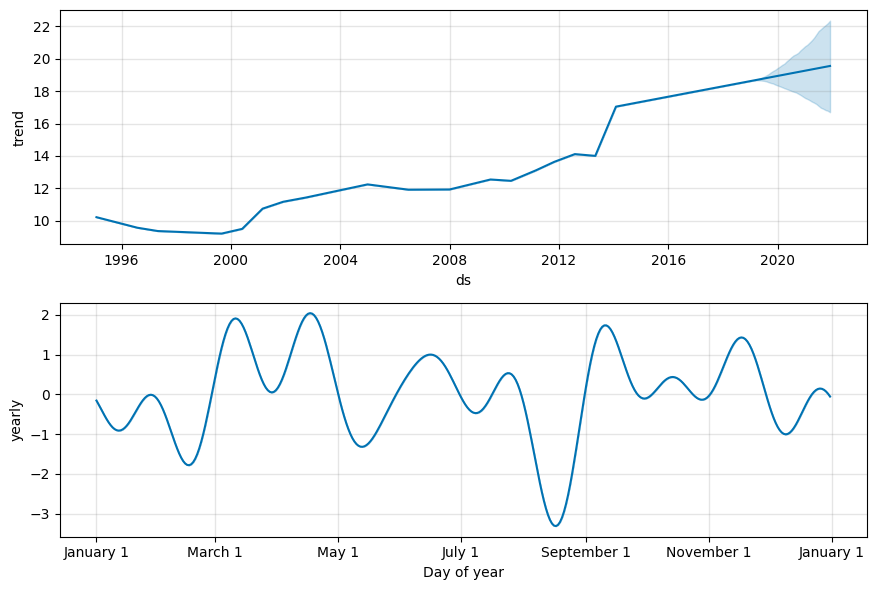

In [24]:
prophet_components_fig = m.plot_components(forecast)

## SARIMA 

In [25]:
ad_fuller_result = adfuller(df['y'])

print(f'ADF Statistic: {ad_fuller_result[0]}')
print(f'p-value: {ad_fuller_result[1]}')

ADF Statistic: 0.31276604677391195
p-value: 0.9779226633224507


In [26]:
y_diff = np.diff(df['y'], n=1)

ad_fuller_result = adfuller(y_diff)

print(f'ADF Statistic: {ad_fuller_result[0]}')
print(f'p-value: {ad_fuller_result[1]}')

ADF Statistic: -16.784744900608814
p-value: 1.2558701587332352e-29


In [27]:
def optimize_SARIMAX(endog: Union[pd.Series, list], exog: Union[pd.Series, list], order_list: list, d: int, D: int, s: int) -> pd.DataFrame:
    
    results = []
    
    for order in tqdm(order_list):
        try: 
            model = SARIMAX(
                endog,
                exog,
                order=(order[0], d, order[1]),
                seasonal_order=(order[2], D, order[3], s),
                simple_differencing=False).fit(disp=False)
        except:
            continue
            
        aic = model.aic
        results.append([order, model.aic])
        
    result_df = pd.DataFrame(results)
    result_df.columns = ['(p,q,P,Q)', 'AIC']
    
    #Sort in ascending order, lower AIC is better
    result_df = result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)
    
    return result_df

In [28]:
ps = range(1, 4, 1)
qs = range(1, 4, 1)
Ps = range(1, 4, 1)
Qs = range(1, 4, 1)

order_list = list(product(ps, qs, Ps, Qs))

d = 1
D = 0
s = 12

In [29]:
SARIMA_result_df = optimize_SARIMAX(train['y'], None, order_list, d, D, s)
SARIMA_result_df

100%|██████████| 81/81 [01:12<00:00,  1.11it/s]


,"(p,q,P,Q)",AIC
0,"(2, 3, 1, 1)",59.502974
1,"(2, 3, 1, 2)",60.476955
2,"(3, 2, 1, 1)",60.641443
3,"(2, 3, 2, 1)",60.867651
4,"(3, 2, 2, 1)",61.562658
...,...,...
75,"(3, 3, 1, 3)",78.717319
76,"(3, 3, 1, 2)",79.322033
77,"(3, 3, 1, 1)",79.334220
78,"(3, 3, 3, 3)",79.469590


In [30]:
SARIMA_model = SARIMAX(train['y'], order=(2,1,3), seasonal_order=(1,0,1,12), simple_differencing=False)
SARIMA_model_fit = SARIMA_model.fit(disp=False)

print(SARIMA_model_fit.summary())

                                      SARIMAX Results                                       
Dep. Variable:                                    y   No. Observations:                  287
Model:             SARIMAX(2, 1, 3)x(1, 0, [1], 12)   Log Likelihood                 -21.751
Date:                              Fri, 26 Jun 2026   AIC                             59.503
Time:                                      07:23:34   BIC                             88.751
Sample:                                           0   HQIC                            71.226
                                              - 287                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.2327      0.044     28.028      0.000       1.147       1.319
ar.L2         -0.92

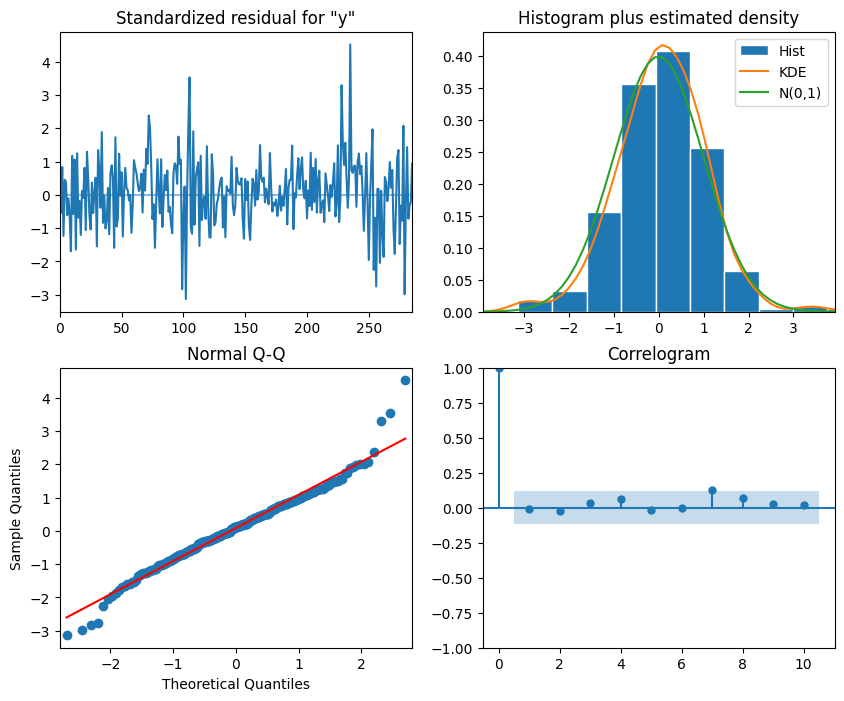

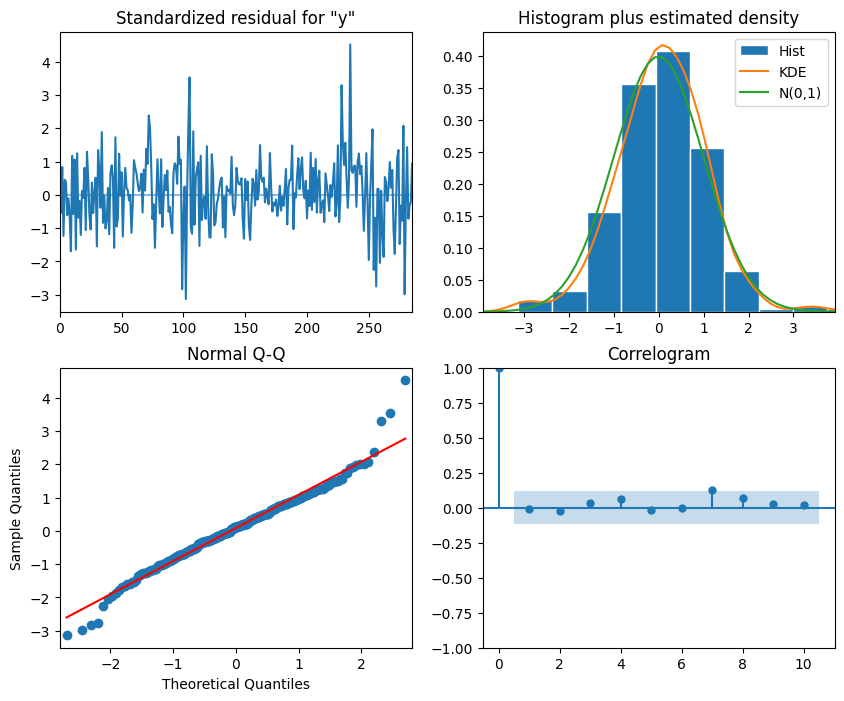

In [31]:
SARIMA_model_fit.plot_diagnostics(figsize=(10,8))

In [32]:
residuals = SARIMA_model_fit.resid

lb_result = acorr_ljungbox(residuals, lags=np.arange(1, 11, 1))

pvalue = lb_result['lb_pvalue'].to_numpy()

print(pvalue)

[0.91237942 0.94893174 0.9704182  0.98581833 0.99621305 0.99902175
 0.99977221 0.99994569 0.99998312 0.99992348]


In [33]:
SARIMA_pred = SARIMA_model_fit.get_prediction(287, 322).predicted_mean

test['SARIMA_pred'] = SARIMA_pred

In [34]:
SARIMA_mae = mean_absolute_error(test['y'], test['SARIMA_pred'])

print(SARIMA_mae)

0.6745632133233112


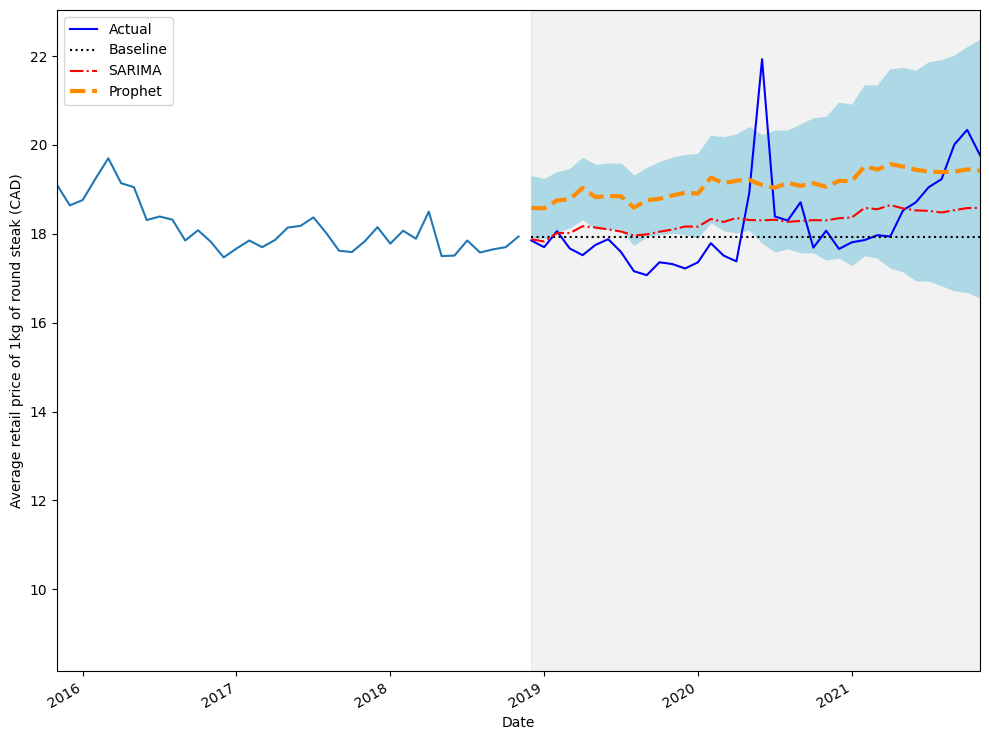

In [35]:
fig, ax = plt.subplots()

ax.plot(train['y'])
ax.plot(test['y'], 'b-', label='Actual')
ax.plot(test['Baseline'], 'k:', label='Baseline')
ax.plot(test['SARIMA_pred'], 'r-.', label='SARIMA')
ax.plot(test['yhat'], color='darkorange', ls='--', lw=3, label='Prophet')

ax.set_xlabel('Date')
ax.set_ylabel('Average retail price of 1kg of round steak (CAD)')

ax.axvspan(287, 322, color='#808080', alpha=0.1)

ax.legend(loc='best')

plt.xticks(np.arange(0, 322, 12), np.arange(1995, 2022, 1))
plt.fill_between(x=test.index, y1=test['yhat_lower'], y2=test['yhat_upper'], color='lightblue')
plt.xlim(250, 322)

fig.autofmt_xdate()
plt.tight_layout()